# 프로젝트 1: 생산관리 - OEE & 생산 효율 분석

## 프로젝트 배경

당신은 **한국정밀산업(주)** 스마트팩토리팀의 데이터 분석가입니다.  
공장에는 **3개 라인(A·B·C)**, 총 **12대의 가공설비**가 가동 중이며, **6종의 제품**을 생산합니다.

최근 경영진으로부터 다음과 같은 요청이 내려왔습니다:

> *"우리 공장 설비들의 종합효율(OEE)을 체계적으로 분석해 주세요.  
> 어떤 라인, 어떤 설비에서 로스가 가장 크고,  
> 개선 활동(3월 시작) 이후 실제로 효과가 있었는지 데이터로 보여주세요."*

### 분석 목표
1. **데이터 품질 확인** - 현장 데이터의 결측치·이상치를 파악하고 전처리
2. **OEE 산출** - 가동률 × 성능률 × 양품률을 설비·라인·기간별로 계산
3. **Six Big Losses 분석** - 비가동 유형별 로스를 정량화
4. **개선 효과 검증** - 3월 전/후 OEE 변화를 통계적으로 비교
5. **경영진 보고용 대시보드** - 핵심 KPI를 한눈에 보여주는 시각화

### 데이터 설명

| 파일 | 설명 | 주요 컬럼 |
|------|------|----------|
| `p1_equipment.csv` | 설비 마스터 (13대) | equipment_id, line, equipment_type, rated_capacity_per_hour |
| `p1_product.csv` | 제품 마스터 (6종) | product_code, standard_cycle_time_sec, target_defect_rate_pct |
| `p1_production_log.csv` | 일별 생산 실적 (~3,100건) | production_date, shift, actual_quantity, good_quantity, actual_operating_time_min |
| `p1_downtime_log.csv` | 비가동/로스 기록 (~430건) | downtime_type, duration_min, cause |

### OEE (Overall Equipment Effectiveness) 공식

```
OEE = 가동률(Availability) × 성능률(Performance) × 양품률(Quality)

가동률 = 실제가동시간 / 계획가동시간
성능률 = (실제생산량 × 기준사이클타임) / 실제가동시간
양품률 = 양품수량 / 실제생산량
```

---

## Part 0: 환경 설정 및 데이터 로드

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
sns.set_style('whitegrid')

# 데이터 로드
equipment = pd.read_csv('../data/project1/p1_equipment.csv', encoding='utf-8-sig')
product = pd.read_csv('../data/project1/p1_product.csv', encoding='utf-8-sig')
prod_log = pd.read_csv('../data/project1/p1_production_log.csv', encoding='utf-8-sig')
downtime = pd.read_csv('../data/project1/p1_downtime_log.csv', encoding='utf-8-sig')

# 날짜 컬럼 변환
prod_log['production_date'] = pd.to_datetime(prod_log['production_date'])
downtime['date'] = pd.to_datetime(downtime['date'])
downtime['start_time'] = pd.to_datetime(downtime['start_time'])
downtime['end_time'] = pd.to_datetime(downtime['end_time'])

print('데이터 로드 완료!')
print(f'설비: {len(equipment)}건 | 제품: {len(product)}건 | 생산실적: {len(prod_log)}건 | 비가동: {len(downtime)}건')

데이터 로드 완료!
설비: 13건 | 제품: 6건 | 생산실적: 3120건 | 비가동: 427건


In [2]:
from koreanize_matplotlib import koreanize
koreanize()

---
## Part 1: 데이터 탐색 및 전처리 (25점)

현장에서 수집된 데이터는 **완벽하지 않습니다.**  
센서 오류, 기록 누락, 입력 실수 등으로 결측치와 이상치가 포함되어 있습니다.  
분석 전에 데이터 품질을 반드시 확인하고 전처리해야 합니다.

> **현업 포인트**: 데이터를 신뢰하지 마세요. 항상 먼저 확인하세요.

### 문제 1-1: 4개 데이터프레임 기본 탐색 (5점)

각 데이터프레임의 shape, dtypes, 처음 5행을 확인하세요.  
특히 **생산 실적(prod_log)**의 컬럼별 결측치 수와 비율을 확인하세요.

**확인할 것:**
- 어떤 컬럼에 결측치가 있는가?
- 결측치 비율이 분석에 영향을 줄 수준인가?

In [3]:
# 여기에 코드 작성
equipment['equipment_id'].nunique()

13

In [4]:
equipment['manufacturer'].unique()

array(['화낙', 'DMG모리', '브라더', '마작', '두산'], dtype=object)

In [5]:
equipment.isna().sum()

equipment_id               0
equipment_name             0
line                       0
equipment_type             0
manufacturer               0
install_date               0
rated_capacity_per_hour    0
dtype: int64

In [6]:
product

,product_code,product_name,standard_cycle_time_sec,category,weight_kg,target_defect_rate_pct
0,PRD-001,베어링하우징-S,30,하우징,2.5,1.5
1,PRD-002,베어링하우징-M,45,하우징,4.2,2.0
2,PRD-003,샤프트-A,25,샤프트,1.8,1.0
3,PRD-004,샤프트-B,35,샤프트,2.8,2.5
4,PRD-005,기어박스커버,60,커버,5.5,3.0
5,PRD-006,플랜지,20,플랜지,1.2,1.0


In [7]:
prod_log['shift'].unique()

array(['주간', '야간'], dtype=object)

In [8]:
prod_log.isna().sum()

log_id                         0
production_date                0
shift                          0
equipment_id                   0
product_code                   0
planned_quantity               0
actual_quantity                0
good_quantity                 84
defect_quantity                0
planned_time_min               0
actual_operating_time_min     66
setup_time_min               111
operator_id                    0
dtype: int64

In [9]:
downtime['downtime_type'].unique()

array(['소정지', '설비고장', '셋업/조정', '속도저하', '초기불량', '계획정지'], dtype=object)

In [10]:
downtime.isna().sum()

downtime_id       0
date              0
equipment_id      0
shift             0
downtime_type     0
start_time        0
end_time          0
duration_min      5
cause            15
line              0
dtype: int64

### 문제 1-2: 생산 실적 결측치 처리 (5점)

생산 현장에서 `good_quantity`(양품수량)가 비어있는 건은 **품질 검사가 아직 완료되지 않은 것**입니다.  
이런 경우 현업에서는 보통 `actual_quantity - defect_quantity`로 추정합니다.

`setup_time_min`이 비어있는 건은 **교대 인수인계 시 기록 누락**입니다.  
해당 설비의 평균 셋업 시간으로 대체하세요.

`actual_operating_time_min`이 비어있는 건도 해당 설비의 평균값으로 대체하세요.

**처리 후 결측치가 0인지 확인하세요.**

In [11]:
prod_log['good_quantity'] = prod_log['good_quantity'].fillna(prod_log['actual_quantity'] - prod_log['defect_quantity'])

In [12]:
prod_log.isna().sum()

log_id                         0
production_date                0
shift                          0
equipment_id                   0
product_code                   0
planned_quantity               0
actual_quantity                0
good_quantity                  0
defect_quantity                0
planned_time_min               0
actual_operating_time_min     66
setup_time_min               111
operator_id                    0
dtype: int64

In [13]:
prod_log.columns

Index(['log_id', 'production_date', 'shift', 'equipment_id', 'product_code',
       'planned_quantity', 'actual_quantity', 'good_quantity',
       'defect_quantity', 'planned_time_min', 'actual_operating_time_min',
       'setup_time_min', 'operator_id'],
      dtype='object')

In [14]:
prod_log.groupby('equipment_id')['setup_time_min'].transform('mean')

0       21.791339
1       21.726908
2       21.870079
3       20.943775
4       21.686047
          ...    
3115    20.957031
3116    21.720000
3117    22.023810
3118    22.324219
3119    22.247899
Name: setup_time_min, Length: 3120, dtype: float64

In [15]:
prod_log['setup_time_min'] = prod_log['setup_time_min'].fillna( prod_log.groupby('equipment_id')['setup_time_min'].transform('mean') )

In [16]:
prod_log.isna().sum()

log_id                        0
production_date               0
shift                         0
equipment_id                  0
product_code                  0
planned_quantity              0
actual_quantity               0
good_quantity                 0
defect_quantity               0
planned_time_min              0
actual_operating_time_min    66
setup_time_min                0
operator_id                   0
dtype: int64

In [17]:
prod_log['actual_operating_time_min'] = prod_log['actual_operating_time_min'].fillna(  prod_log.groupby('equipment_id')['actual_operating_time_min'].transform('mean'))

In [18]:
prod_log.isna().sum()

log_id                       0
production_date              0
shift                        0
equipment_id                 0
product_code                 0
planned_quantity             0
actual_quantity              0
good_quantity                0
defect_quantity              0
planned_time_min             0
actual_operating_time_min    0
setup_time_min               0
operator_id                  0
dtype: int64

In [19]:
# 여기에 코드 작성


### 문제 1-3: 이상치 탐지 (5점)

생산량이 비정상적으로 낮은 건이 있을 수 있습니다 (자재 문제, 긴급 정지 등).  
`actual_quantity` 컬럼에서 **IQR 방법**으로 이상치를 탐지하세요.

1. Q1, Q3, IQR을 계산하세요
2. 하한(Q1 - 1.5×IQR) 미만인 이상치를 찾으세요
3. 이상치가 몇 건인지, 어떤 설비에서 주로 발생하는지 확인하세요
4. 이상치에 `is_outlier` 플래그 컬럼을 추가하세요 (True/False)

> **현업 포인트**: 이상치를 무조건 제거하면 안 됩니다. 원인을 파악하고, 분석 목적에 따라 포함/제외를 결정합니다.

In [36]:
prod_log['actual_quantity'].describe()

count    3120.000000
mean      716.694231
std       252.705636
min        52.000000
25%       503.000000
50%       729.000000
75%       902.000000
max      1380.000000
Name: actual_quantity, dtype: float64

In [35]:
# 여기에 코드 작성
Q1 = prod_log['actual_quantity'].quantile(0.25)

In [37]:
Q1

np.float64(503.0)

In [39]:
Q3 = prod_log['actual_quantity'].quantile(0.75)

In [50]:
Q3

np.float64(902.0)

In [41]:
IQR = Q3 - Q1

In [42]:
IQR

np.float64(399.0)

In [44]:
lower_bound = Q1 - 1.5 * IQR

In [51]:
lower_bound

np.float64(-95.5)

In [52]:
prod_log.loc[ prod_log['actual_quantity'] < lower_bound , ]

,log_id,production_date,shift,equipment_id,product_code,planned_quantity,actual_quantity,good_quantity,defect_quantity,planned_time_min,actual_operating_time_min,setup_time_min,operator_id


### 문제 1-4: 마스터 데이터 결합 (5점)

생산 실적에 **설비 정보**와 **제품 정보**를 결합하세요.

1. `prod_log`에 `equipment` 테이블의 `line`, `equipment_type`, `equipment_name`을 left join
2. 이어서 `product` 테이블의 `product_name`, `standard_cycle_time_sec`, `category`를 left join
3. 결합 후 행 수가 변하지 않았는지 확인하세요
4. 결합된 데이터프레임을 `df`로 저장하세요

In [55]:
df = pd.merge(prod_log, equipment[ ['equipment_id','line', 'equipment_type', 'equipment_name' ] ], 
         on= 'equipment_id', how='left')

In [56]:
df.columns

Index(['log_id', 'production_date', 'shift', 'equipment_id', 'product_code',
       'planned_quantity', 'actual_quantity', 'good_quantity',
       'defect_quantity', 'planned_time_min', 'actual_operating_time_min',
       'setup_time_min', 'operator_id', 'line', 'equipment_type',
       'equipment_name'],
      dtype='object')

In [57]:
product.columns

Index(['product_code', 'product_name', 'standard_cycle_time_sec', 'category',
       'weight_kg', 'target_defect_rate_pct'],
      dtype='object')

In [59]:
df = pd.merge(df, product[['product_code', 'product_name', 'standard_cycle_time_sec', 'category']],
        on = 'product_code', how='left')

In [60]:
df.head(1)

,log_id,production_date,shift,equipment_id,product_code,planned_quantity,actual_quantity,good_quantity,defect_quantity,planned_time_min,actual_operating_time_min,setup_time_min,operator_id,line,equipment_type,equipment_name,product_name,standard_cycle_time_sec,category
0,LOG-00001,2024-01-01,주간,EQ-A01,PRD-003,979,753,743.0,10,480,351.9,15.0,OP-004,A라인,CNC선반,CNC선반-A1,샤프트-A,25,샤프트


### 문제 1-5: 분석용 파생 컬럼 생성 (5점)

OEE 분석을 위해 다음 파생 컬럼을 만드세요:

1. `month` - 생산월 (1~6)
2. `week` - 주차 (ISO 주차)
3. `weekday` - 요일명 (월요일~토요일)
4. `defect_rate` - 불량률 (%) = defect_quantity / actual_quantity × 100
5. `achievement_rate` - 계획 달성률 (%) = actual_quantity / planned_quantity × 100

각 컬럼의 기본 통계(describe)를 확인하세요.

In [61]:
df.columns

Index(['log_id', 'production_date', 'shift', 'equipment_id', 'product_code',
       'planned_quantity', 'actual_quantity', 'good_quantity',
       'defect_quantity', 'planned_time_min', 'actual_operating_time_min',
       'setup_time_min', 'operator_id', 'line', 'equipment_type',
       'equipment_name', 'product_name', 'standard_cycle_time_sec',
       'category'],
      dtype='object')

In [68]:
df['month'] = df['production_date'].dt.month

In [74]:
df['week'] = df['production_date'].dt.isocalendar()['week'].astype(int)

In [83]:
week_name = {0:'월요일',1:'화요일',2:'수요일',3:'목요일',4:'금요일',5:'토요일',6: '일요일'}
def get_name(number) :
    return week_name[number]

In [86]:
df['weekday'] = df['production_date'].dt.weekday.apply( get_name )

In [89]:
df['defect_rate'] = (df['defect_quantity'] / df['actual_quantity'] * 100).round(2)

In [92]:
df['achievement_rate'] = (df['actual_quantity'] / df['planned_quantity'] * 100).round(2)

---
## Part 2: OEE 산출 (25점)

**OEE(Overall Equipment Effectiveness, 설비종합효율)**은 제조업에서 가장 중요한 KPI 중 하나입니다.  
세계적 제조기업들의 OEE 벤치마크:

| 등급 | OEE | 의미 |
|------|-----|------|
| World Class | 85% 이상 | 글로벌 상위 |
| Good | 70~85% | 양호 |
| Average | 55~70% | 개선 필요 |
| Poor | 55% 미만 | 심각한 로스 |

> **왜 OEE인가?** 단순 가동률만 보면 '속도 로스'와 '품질 로스'를 놓칩니다.  
> OEE는 시간·속도·품질 세 관점을 곱해 **진짜 효율**을 보여줍니다.

### 문제 2-1: 건별 OEE 3요소 계산 (10점)

각 생산 실적 건(행)마다 OEE 3요소를 계산하세요.  
이상치(`is_outlier == True`)는 **제외**하고 계산하세요.

```
가동률(availability) = actual_operating_time_min / planned_time_min
성능률(performance) = (actual_quantity × standard_cycle_time_sec / 60) / actual_operating_time_min
양품률(quality)     = good_quantity / actual_quantity
OEE               = availability × performance × quality
```

1. 위 4개 컬럼을 `df`에 추가하세요 (소수점, 0~1 범위)
2. OEE의 기본 통계(describe)를 확인하세요
3. OEE가 1을 초과하는 건이 있는지 확인하고, 있다면 1로 클리핑하세요

> **주의**: 성능률이 1을 초과할 수 있습니다 (기준 사이클타임보다 빠르게 생산한 경우).  
> 현업에서는 보통 1.0으로 제한(clip)합니다.

In [93]:
df.columns

Index(['log_id', 'production_date', 'shift', 'equipment_id', 'product_code',
       'planned_quantity', 'actual_quantity', 'good_quantity',
       'defect_quantity', 'planned_time_min', 'actual_operating_time_min',
       'setup_time_min', 'operator_id', 'line', 'equipment_type',
       'equipment_name', 'product_name', 'standard_cycle_time_sec', 'category',
       'month', 'week', 'weekday', 'defect_rate', 'achievement_rate'],
      dtype='object')

In [95]:
df['availablity'] = df['actual_operating_time_min'] / df['planned_time_min'] 

In [98]:
df['performance'] = ( df['actual_quantity'] * df['standard_cycle_time_sec'] / 60 ) / df['actual_operating_time_min']

In [100]:
df['quality'] = df['good_quantity'] / df['actual_quantity']

In [102]:
df['performance'] = df['performance'].clip(upper = 1.0)

In [103]:
df['availablity'] = df['availablity'].clip(upper = 1.0)

In [105]:
df['oee'] = df['availablity'] * df['performance'] * df['quality']

In [108]:
(df['oee'] > 1.0).sum()

np.int64(0)

In [109]:
df['oee'].mean()

np.float64(0.7436274421673599)

In [110]:
df['oee'].describe()

count    3120.000000
mean        0.743627
std         0.105713
min         0.096007
25%         0.682682
50%         0.750868
75%         0.813368
max         0.956250
Name: oee, dtype: float64

### 문제 2-2: 설비별 OEE 집계 (5점)

설비별(equipment_id) 평균 OEE와 3요소를 집계하세요.

1. 설비별 평균 `availability`, `performance`, `quality`, `oee`를 계산
2. OEE 기준 내림차순 정렬
3. 결과에 `equipment_name`과 `line`을 포함
4. OEE가 가장 낮은 설비 3대는 어디인가?
5. 어떤 요소(가동률/성능률/양품률)가 OEE를 끌어내리고 있는가?

In [111]:
df.columns

Index(['log_id', 'production_date', 'shift', 'equipment_id', 'product_code',
       'planned_quantity', 'actual_quantity', 'good_quantity',
       'defect_quantity', 'planned_time_min', 'actual_operating_time_min',
       'setup_time_min', 'operator_id', 'line', 'equipment_type',
       'equipment_name', 'product_name', 'standard_cycle_time_sec', 'category',
       'month', 'week', 'weekday', 'defect_rate', 'achievement_rate',
       'availablity', 'performance', 'quality', 'oee'],
      dtype='object')

In [115]:
# 여기에 코드 작성
equip_oee = df.groupby('equipment_id').agg( {'availablity' : 'mean' ,
                                'performance' : 'mean',
                                'quality' : 'mean',
                                'oee' : 'mean'}).sort_values('oee', ascending=False)

In [116]:
equip_oee

,availablity,performance,quality,oee
equipment_id,,,,
EQ-B02,0.877976,0.952091,0.989244,0.827126
EQ-B04,0.883420,0.938313,0.992040,0.822381
EQ-B01,0.876626,0.949095,0.988051,0.822168
EQ-B03,0.877421,0.952771,0.979067,0.818694
EQ-C02,0.836890,0.912994,0.985817,0.753474
EQ-C01,0.831759,0.916762,0.985037,0.751091
EQ-C04,0.831600,0.912093,0.989775,0.750806
EQ-C03,0.825974,0.917282,0.972363,0.736975
EQ-A04,0.789697,0.886964,0.987322,0.691929


In [120]:
equip_oee = pd.merge(equip_oee , equipment[['equipment_id','equipment_name','line']] , 
         on = 'equipment_id' )

In [125]:
equip_oee.tail(3).sort_values('oee').reset_index(drop=True)

,equipment_id,availablity,performance,quality,oee,equipment_name,line
0,EQ-A03,0.698127,0.878418,0.964572,0.592378,밀링머신-A3,A라인
1,EQ-A01,0.787264,0.879337,0.980208,0.678933,CNC선반-A1,A라인
2,EQ-A02,0.783246,0.884348,0.980889,0.679595,CNC선반-A2,A라인


### 문제 2-3: 라인별·월별 OEE 추이 (10점)

경영진은 **3월에 시작한 설비 개선 활동**의 효과를 확인하고 싶어합니다.

1. 라인별(A/B/C) + 월별 평균 OEE를 피벗 테이블로 만드세요  
   - index='line', columns='month', values='oee'
2. 해당 피벗 테이블을 **히트맵**으로 시각화하세요
   - `annot=True, fmt='.1%'` (퍼센트 포맷)
   - `cmap='RdYlGn'` (빨강→노랑→녹색)
3. 전체 월별 OEE 추이를 **라인 차트**로 그리세요
   - 라인별 색상 구분
   - 3월에 세로 점선 추가 (`axvline`)하여 '개선 활동 시작' 표시
4. 개선 전(1~3월)과 개선 후(4~6월) 평균 OEE를 비교하는 표를 출력하세요

In [127]:
df.columns

Index(['log_id', 'production_date', 'shift', 'equipment_id', 'product_code',
       'planned_quantity', 'actual_quantity', 'good_quantity',
       'defect_quantity', 'planned_time_min', 'actual_operating_time_min',
       'setup_time_min', 'operator_id', 'line', 'equipment_type',
       'equipment_name', 'product_name', 'standard_cycle_time_sec', 'category',
       'month', 'week', 'weekday', 'defect_rate', 'achievement_rate',
       'availablity', 'performance', 'quality', 'oee'],
      dtype='object')

In [130]:
line_month_oee = df.pivot_table(index='line', columns='month', values='oee', aggfunc='mean')

In [131]:
line_month_oee

month,1,2,3,4,5,6
line,,,,,,
A라인,0.632957,0.642248,0.642356,0.681291,0.682239,0.681329
B라인,0.801524,0.803744,0.802446,0.836706,0.847307,0.843809
C라인,0.727967,0.729795,0.730831,0.768353,0.758238,0.773865


In [136]:
df['oee'].describe()

count    3120.000000
mean        0.743627
std         0.105713
min         0.096007
25%         0.682682
50%         0.750868
75%         0.813368
max         0.956250
Name: oee, dtype: float64

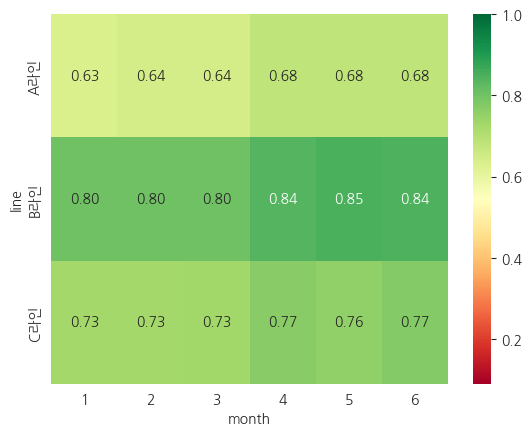

In [138]:
sns.heatmap(data= line_month_oee, annot=True, fmt='.2f',cmap='RdYlGn',
           vmin = 0.09, vmax = 1)
plt.show()

In [141]:
df_1 = line_month_oee.loc[ 'A라인' ,   ]

In [142]:
df_1

month
1    0.632957
2    0.642248
3    0.642356
4    0.681291
5    0.682239
6    0.681329
Name: A라인, dtype: float64

In [147]:
df_2 = line_month_oee.loc['B라인' , ]

In [149]:
df_3 = line_month_oee.loc['C라인' , ]

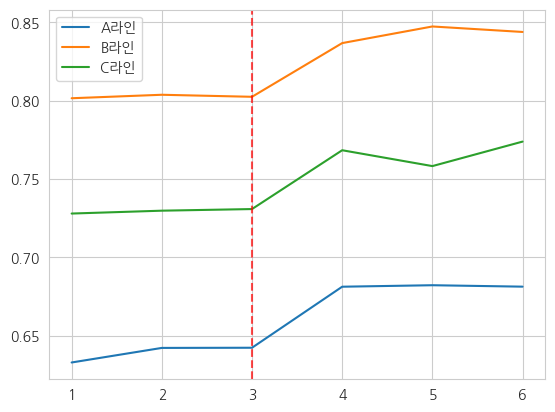

In [156]:
plt.plot(df_1.index, df_1.values, label='A라인')
plt.plot(df_2.index, df_2.values, label='B라인')
plt.plot(df_3.index, df_3.values, label='C라인')
plt.axvline(x=3, color='red', linestyle='--', alpha=0.7)
plt.legend()
plt.show()

In [160]:
(line_month_oee[4] - line_month_oee[3]).round(3)

line
A라인    0.039
B라인    0.034
C라인    0.038
dtype: float64

---
## Part 3: 심화 분석 (20점)

OEE 숫자만으로는 부족합니다.  
경영진과 현장 관리자가 **구체적인 액션**을 취하려면,  
교대조·제품·설비 유형별로 **어디서, 왜** 로스가 발생하는지 알아야 합니다.

### 문제 3-1: 교대조별 OEE 비교 (5점)

야간 근무는 주간보다 품질이 떨어진다는 현장의 목소리가 있습니다.  
데이터로 확인해 보세요.

1. 교대조별(주간/야간) OEE 3요소 + OEE 평균을 비교표로 출력
2. **박스플롯**으로 교대조별 OEE 분포를 비교하세요
   - 같은 Figure에 OEE, 가동률, 성능률, 양품률 4개 subplot (2×2)
3. 주간 vs 야간 차이가 통계적으로 유의한지 **t-test**를 수행하세요
   - `from scipy import stats`
   - p-value < 0.05이면 유의한 차이

In [161]:
df.columns

Index(['log_id', 'production_date', 'shift', 'equipment_id', 'product_code',
       'planned_quantity', 'actual_quantity', 'good_quantity',
       'defect_quantity', 'planned_time_min', 'actual_operating_time_min',
       'setup_time_min', 'operator_id', 'line', 'equipment_type',
       'equipment_name', 'product_name', 'standard_cycle_time_sec', 'category',
       'month', 'week', 'weekday', 'defect_rate', 'achievement_rate',
       'availablity', 'performance', 'quality', 'oee'],
      dtype='object')

In [172]:
shift_compare = df.groupby('shift')[ ['availablity', 'performance', 'quality', 'oee' ] ].mean()

In [173]:
shift_compare = shift_compare.round(2)

In [174]:
shift_compare

,availablity,performance,quality,oee
shift,,,,
야간,0.82,0.91,0.98,0.73
주간,0.83,0.92,0.98,0.75


In [175]:
df

,log_id,production_date,shift,equipment_id,product_code,planned_quantity,actual_quantity,good_quantity,defect_quantity,planned_time_min,...,category,month,week,weekday,defect_rate,achievement_rate,availablity,performance,quality,oee
0,LOG-00001,2024-01-01,주간,EQ-A01,PRD-003,979,753,743.0,10,480,...,샤프트,1,1,월요일,1.33,76.92,0.733125,0.891589,0.986720,0.644965
1,LOG-00002,2024-01-01,주간,EQ-A02,PRD-001,816,690,680.0,10,480,...,하우징,1,1,월요일,1.45,84.56,0.839375,0.856292,0.985507,0.708333
2,LOG-00003,2024-01-01,주간,EQ-A03,PRD-004,699,426,407.0,19,480,...,샤프트,1,1,월요일,4.46,60.94,0.652708,0.793169,0.955399,0.494618
3,LOG-00004,2024-01-01,주간,EQ-A04,PRD-003,979,745,732.0,13,480,...,샤프트,1,1,월요일,1.74,76.10,0.756458,0.854907,0.982550,0.635417
4,LOG-00005,2024-01-01,주간,EQ-B02,PRD-003,979,954,953.0,1,480,...,샤프트,1,1,월요일,0.10,97.45,0.919375,0.900748,0.998952,0.827257
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3115,LOG-03116,2024-06-29,주간,EQ-B04,PRD-006,1224,1239,1234.0,5,480,...,플랜지,6,26,토요일,0.40,101.23,0.892083,0.964503,0.995964,0.856944
3116,LOG-03117,2024-06-29,주간,EQ-C01,PRD-002,544,462,454.0,8,480,...,하우징,6,26,토요일,1.73,84.93,0.814167,0.886643,0.982684,0.709375
3117,LOG-03118,2024-06-29,주간,EQ-C02,PRD-001,816,843,831.0,12,480,...,하우징,6,26,토요일,1.42,103.31,0.937917,0.936251,0.985765,0.865625
3118,LOG-03119,2024-06-29,주간,EQ-C03,PRD-004,699,708,691.0,17,480,...,샤프트,6,26,토요일,2.40,101.29,0.917083,0.938210,0.975989,0.839757


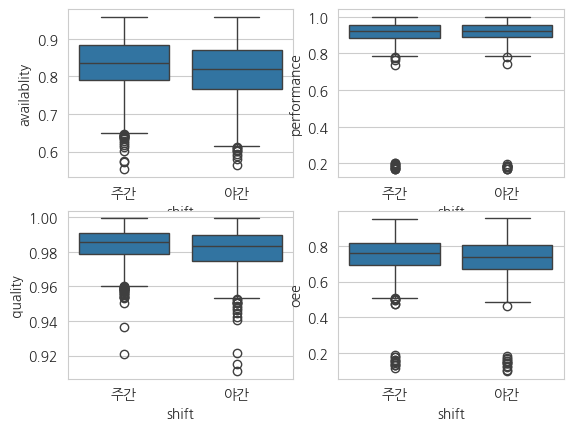

In [178]:
plt.subplot(2, 2, 1)
sns.boxplot(data=df, x='shift', y='availablity' )

plt.subplot(2, 2, 2)
sns.boxplot(data=df, x='shift', y='performance' )

plt.subplot(2, 2, 3)
sns.boxplot(data=df, x='shift', y='quality' )

plt.subplot(2, 2, 4)
sns.boxplot(data=df, x='shift', y='oee' )
plt.show()

In [184]:
day_oee = df.loc[ df['shift'] == '주간' , 'oee' ]

In [187]:
night_oee = df.loc[ df['shift'] == '야간' , 'oee' ]

In [189]:
from scipy import stats

ModuleNotFoundError: No module named 'scipy'

In [190]:
! pip install scipy

   ---------------------------------------- 0.0/41.3 MB ? eta -:--:--
   ------ --------------------------------- 6.8/41.3 MB 38.1 MB/s eta 0:00:01
   -------------- ------------------------- 15.5/41.3 MB 42.4 MB/s eta 0:00:01
   ------------------------ --------------- 24.9/41.3 MB 41.5 MB/s eta 0:00:01
   -------------------------------- ------- 33.6/41.3 MB 41.0 MB/s eta 0:00:01
   ---------------------------------------- 41.3/41.3 MB 39.8 MB/s  0:00:01


In [191]:
from scipy import stats

In [193]:
t_stat, p_value = stats.ttest_ind(day_oee, night_oee )

In [194]:
p_value

np.float64(3.4861104278369175e-06)

In [195]:
if p_value < 0.05 :
    print('유의함')
else :
    print('유의하지 않음')

유의함


In [198]:
day_quality = df.loc[ df['shift'] == '주간' , 'quality'  ]

In [199]:
night_quality = df.loc[ df['shift'] == '야간' , 'quality'  ]

In [201]:
t_stat, p_value = stats.ttest_ind(day_quality, night_quality)

In [202]:
p_value

np.float64(1.5861675482600947e-12)

In [203]:
if p_value < 0.05 :
    print('유의함')
else :
    print('유의하지 않음')

유의함


### 문제 3-2: 설비-제품 매트릭스 분석 (5점)

모든 설비가 모든 제품을 동일하게 잘 만드는 것은 아닙니다.  
**어떤 설비에서 어떤 제품을 만들 때 OEE가 높은지** 매트릭스로 분석하세요.

1. `equipment_id`(행) × `product_code`(열)의 평균 OEE 피벗 테이블
2. **히트맵**으로 시각화 (annot=True, fmt='.1%', cmap='YlGnBu')
3. 가장 OEE가 높은 설비-제품 조합 Top 5, 가장 낮은 조합 Bottom 5를 출력하세요

In [212]:
df.columns

Index(['log_id', 'production_date', 'shift', 'equipment_id', 'product_code',
       'planned_quantity', 'actual_quantity', 'good_quantity',
       'defect_quantity', 'planned_time_min', 'actual_operating_time_min',
       'setup_time_min', 'operator_id', 'line', 'equipment_type',
       'equipment_name', 'product_name', 'standard_cycle_time_sec', 'category',
       'month', 'week', 'weekday', 'defect_rate', 'achievement_rate',
       'availablity', 'performance', 'quality', 'oee'],
      dtype='object')

In [214]:
equip_product_oee = df.pivot_table(index='equipment_id', columns='product_code', values='oee', aggfunc='mean')

In [216]:
df['oee'].describe()

count    3120.000000
mean        0.743627
std         0.105713
min         0.096007
25%         0.682682
50%         0.750868
75%         0.813368
max         0.956250
Name: oee, dtype: float64

In [219]:
equip_product_oee.min().min()

0.5916226160862355

In [222]:
equip_product_oee.max().max()

0.8312375992063492

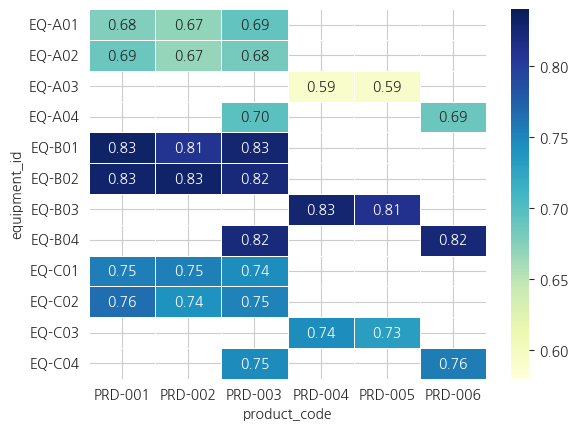

In [224]:
sns.heatmap(data= equip_product_oee, annot=True, fmt='.2f', cmap='YlGnBu', 
           linewidths=0.5, vmin=0.58, vmax=0.84 )
plt.show()

In [225]:
# Top5 / Bottom5

In [229]:
equip_product_oee.stack().sort_values().head(5)

equipment_id  product_code
EQ-A03        PRD-004         0.591623
              PRD-005         0.593157
EQ-A02        PRD-002         0.668005
EQ-A01        PRD-002         0.669454
              PRD-001         0.676840
dtype: float64

In [232]:
equip_product_oee.stack().sort_values(ascending=False).head(5)

equipment_id  product_code
EQ-B01        PRD-001         0.831238
EQ-B02        PRD-002         0.829925
              PRD-001         0.829666
EQ-B03        PRD-004         0.826987
EQ-B01        PRD-003         0.826032
dtype: float64

### 문제 3-3: 요일별 생산성 패턴 분석 (5점)

월요일 아침에는 설비 워밍업이 필요하고, 금요일 오후에는 피로도가 높다는 가설이 있습니다.

1. 요일별 평균 OEE와 불량률을 집계하세요 (월~토)
2. **이중 y축 차트**로 시각화하세요
   - 왼쪽 y축: 평균 OEE (bar 차트)
   - 오른쪽 y축: 평균 불량률 (line 차트, 빨간색)
3. 어떤 요일에 생산성이 가장 좋고, 가장 나쁜가?

In [233]:
# 여기에 코드 작성
df.columns

Index(['log_id', 'production_date', 'shift', 'equipment_id', 'product_code',
       'planned_quantity', 'actual_quantity', 'good_quantity',
       'defect_quantity', 'planned_time_min', 'actual_operating_time_min',
       'setup_time_min', 'operator_id', 'line', 'equipment_type',
       'equipment_name', 'product_name', 'standard_cycle_time_sec', 'category',
       'month', 'week', 'weekday', 'defect_rate', 'achievement_rate',
       'availablity', 'performance', 'quality', 'oee'],
      dtype='object')

In [235]:
df['weekday'].unique()

array(['월요일', '화요일', '수요일', '목요일', '금요일', '토요일'], dtype=object)

In [238]:
daily_stats = df.groupby('weekday')[ ['oee','defect_rate']].mean().reindex(['월요일', '화요일','수요일','목요일','금요일'])

In [239]:
daily_stats

,oee,defect_rate
weekday,,
월요일,0.740789,1.699810
화요일,0.741419,1.739102
수요일,0.744884,1.756109
목요일,0.741117,1.728383
금요일,0.743259,1.747193


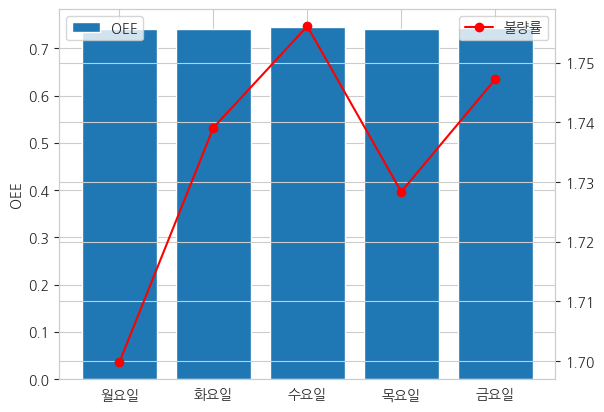

In [250]:
fig, ax1 = plt.subplots()
ax1.bar(daily_stats.index, daily_stats['oee'], label='OEE')
ax1.set_ylabel('OEE')

ax2 = ax1.twinx()
ax2.plot(daily_stats.index, daily_stats['defect_rate'], color='red', marker='o', label='불량률')

ax1.legend(loc='upper left')
ax2.legend()
plt.show()


In [254]:
daily_stats['oee'].idxmin()

'월요일'

In [255]:
daily_stats['defect_rate'].idxmax()

'수요일'

### 문제 3-4: 계획 달성률 vs 불량률 관계 분석 (5점)

"무리하게 생산량을 맞추면 불량이 늘어난다"는 현장의 우려가 있습니다.

1. `achievement_rate`(계획달성률)와 `defect_rate`(불량률)의 **산점도**를 그리세요
   - 라인별 색상 구분 (hue='line')
   - 추세선 포함 (sns.regplot 또는 sns.lmplot)
2. 두 변수의 **상관계수**를 라인별로 계산하세요
3. 달성률 100% 이상인 그룹과 미만인 그룹의 평균 불량률을 비교하세요

In [256]:
# 여기에 코드 작성
df.columns

Index(['log_id', 'production_date', 'shift', 'equipment_id', 'product_code',
       'planned_quantity', 'actual_quantity', 'good_quantity',
       'defect_quantity', 'planned_time_min', 'actual_operating_time_min',
       'setup_time_min', 'operator_id', 'line', 'equipment_type',
       'equipment_name', 'product_name', 'standard_cycle_time_sec', 'category',
       'month', 'week', 'weekday', 'defect_rate', 'achievement_rate',
       'availablity', 'performance', 'quality', 'oee'],
      dtype='object')

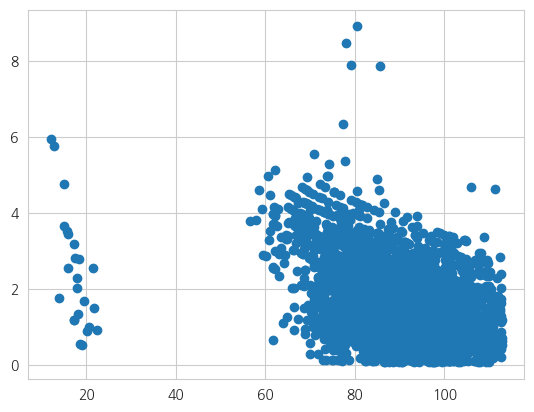

In [257]:
plt.scatter( df['achievement_rate'] , df['defect_rate'] )
plt.show()

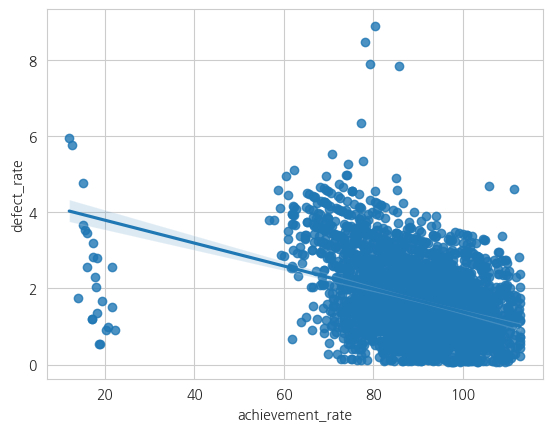

In [260]:
sns.regplot(data= df,  x = 'achievement_rate', y = 'defect_rate')
plt.show()

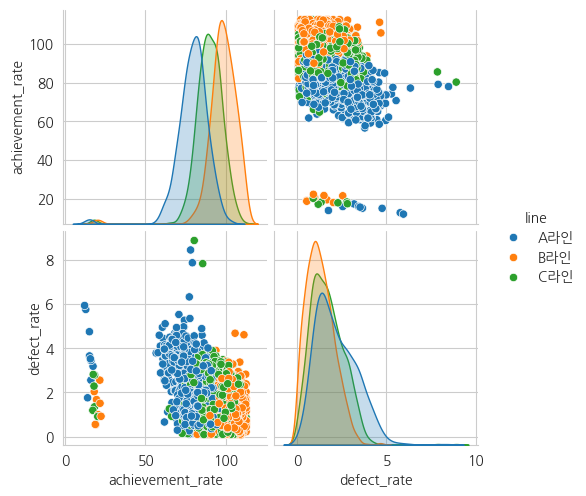

In [261]:
sns.pairplot(data=df[['achievement_rate','defect_rate','line' ] ], hue='line')
plt.show()

In [262]:
df[['achievement_rate','defect_rate' ]].corr()

,achievement_rate,defect_rate
achievement_rate,1.000000,-0.364514
defect_rate,-0.364514,1.000000


In [266]:
df.loc[ df['line'] == 'A라인',['achievement_rate','defect_rate'] ].corr()

,achievement_rate,defect_rate
achievement_rate,1.000000,-0.417156
defect_rate,-0.417156,1.000000


In [267]:
df.loc[ df['line'] == 'B라인',['achievement_rate','defect_rate'] ].corr()

,achievement_rate,defect_rate
achievement_rate,1.000000,0.000875
defect_rate,0.000875,1.000000


In [268]:
df.loc[ df['line'] == 'C라인',['achievement_rate','defect_rate'] ].corr()

,achievement_rate,defect_rate
achievement_rate,1.000000,-0.070289
defect_rate,-0.070289,1.000000


---
## Part 4: Six Big Losses 분석 (15점)

TPM(Total Productive Maintenance)에서는 설비 효율을 떨어뜨리는 원인을  
**6대 로스(Six Big Losses)**로 분류합니다:

| 분류 | 로스 유형 | OEE 영향 |
|------|----------|----------|
| 정지 로스 | ① 설비고장, ② 셋업/조정 | 가동률 ↓ |
| 속도 로스 | ③ 소정지, ④ 속도저하 | 성능률 ↓ |
| 불량 로스 | ⑤ 초기불량, ⑥ 공정불량 | 양품률 ↓ |

비가동 데이터(`downtime`)를 활용하여 로스를 분석합니다.

In [269]:
downtime

,downtime_id,date,equipment_id,shift,downtime_type,start_time,end_time,duration_min,cause,line
0,DT-00001,2024-01-01,EQ-A03,야간,소정지,2024-01-01 22:08:00,2024-01-01 22:18:00,10.0,NaN,A라인
1,DT-00002,2024-01-02,EQ-A01,주간,설비고장,2024-01-02 09:24:00,2024-01-02 11:43:00,139.0,스핀들 이상,A라인
2,DT-00003,2024-01-02,EQ-A04,야간,설비고장,2024-01-02 00:45:00,2024-01-02 01:38:00,53.0,NaN,A라인
3,DT-00004,2024-01-02,EQ-A04,야간,소정지,2024-01-02 03:19:00,2024-01-02 03:35:00,16.0,냉각수 부족,A라인
4,DT-00005,2024-01-02,EQ-C02,주간,셋업/조정,2024-01-02 15:36:00,2024-01-02 16:29:00,53.0,지그 교체,C라인
...,...,...,...,...,...,...,...,...,...,...
422,DT-00423,2024-06-27,EQ-B04,야간,소정지,2024-06-27 03:56:00,2024-06-27 04:09:00,13.0,냉각수 부족,B라인
423,DT-00424,2024-06-28,EQ-A04,주간,초기불량,2024-06-28 12:05:00,2024-06-28 12:18:00,13.0,측정 오차,A라인
424,DT-00425,2024-06-28,EQ-B01,야간,설비고장,2024-06-28 00:33:00,2024-06-28 01:11:00,38.0,유압 누유,B라인
425,DT-00426,2024-06-29,EQ-B04,주간,계획정지,2024-06-29 09:32:00,2024-06-29 11:15:00,NaN,교육/미팅,B라인


### 문제 4-1: 비가동 유형별 분석 (5점)

1. `downtime` 데이터의 결측치를 처리하세요
   - `duration_min` 결측: 같은 `downtime_type`의 평균값으로 대체
   - `cause` 결측: '원인미상'으로 대체
2. 비가동 유형별 **건수**, **총 시간(분)**, **평균 시간(분)**을 집계하세요
3. **파레토 차트**를 그리세요
   - 막대: 유형별 총 비가동 시간 (내림차순)
   - 선: 누적 비율(%)

In [270]:
# 여기에 코드 작성
downtime.isna().sum()

downtime_id       0
date              0
equipment_id      0
shift             0
downtime_type     0
start_time        0
end_time          0
duration_min      5
cause            15
line              0
dtype: int64

In [275]:
downtime['duration_min'] = downtime['duration_min'].fillna(  downtime.groupby('downtime_type')['duration_min'].transform('mean') )

In [276]:
downtime.isna().sum()

downtime_id       0
date              0
equipment_id      0
shift             0
downtime_type     0
start_time        0
end_time          0
duration_min      0
cause            15
line              0
dtype: int64

In [278]:
downtime['cause'] = downtime['cause'].fillna('원인미상')

In [279]:
downtime.isna().sum()

downtime_id      0
date             0
equipment_id     0
shift            0
downtime_type    0
start_time       0
end_time         0
duration_min     0
cause            0
line             0
dtype: int64

In [280]:
downtime.columns

Index(['downtime_id', 'date', 'equipment_id', 'shift', 'downtime_type',
       'start_time', 'end_time', 'duration_min', 'cause', 'line'],
      dtype='object')

In [283]:
loss_summary = downtime.groupby('downtime_type').agg( 건수=('downtime_id','count'), 
                                       총시간=('duration_min', 'sum'),
                                       평균시간=('duration_min' , 'mean') )

In [286]:
loss_summary = loss_summary.sort_values('총시간', ascending=False)

In [294]:
loss_summary['비율'] = (loss_summary['총시간'] / loss_summary['총시간'].sum() * 100).round(2)

In [298]:
loss_summary['누적비율'] = loss_summary['비율'].cumsum()

In [299]:
loss_summary

,건수,총시간,평균시간,비율,누적비율
downtime_type,,,,,
설비고장,115,15182.017544,132.017544,52.78,52.78
속도저하,69,4906.102941,71.102941,17.06,69.84
계획정지,47,3887.717391,82.717391,13.52,83.36
셋업/조정,74,2726.000000,36.837838,9.48,92.84
초기불량,38,1033.388889,27.194444,3.59,96.43
소정지,84,1030.000000,12.261905,3.58,100.01


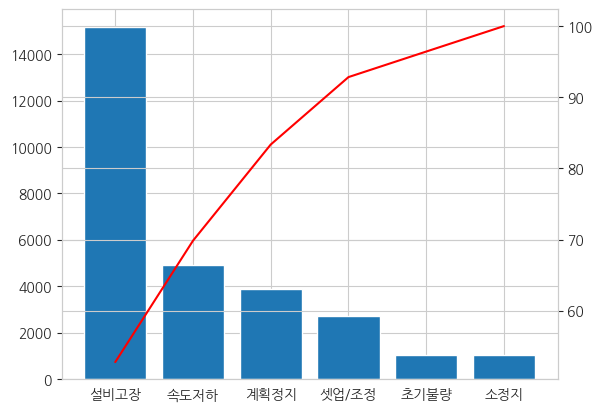

In [301]:
fig, ax1 = plt.subplots()
ax1.bar(loss_summary.index, loss_summary['총시간'])

ax2 = ax1.twinx()
ax2.plot(loss_summary.index, loss_summary['누적비율'] ,color='red' )

plt.show()

### 문제 4-2: 설비별 비가동 패턴 분석 (5점)

어떤 설비에서 어떤 유형의 로스가 집중되는지 파악합니다.

1. `equipment_id`(행) × `downtime_type`(열)의 총 비가동 시간 피벗 테이블
2. **스택 바 차트**로 시각화하세요
   - 설비별 누적 막대그래프
   - 각 유형별 색상 구분
3. 비가동 시간이 가장 긴 설비 Top 3는? 주로 어떤 유형인가?
4. 비가동 기록이 없는 설비가 있는지 확인하세요 (equipment 테이블과 left join)

In [305]:
# 여기에 코드 작성
equip_downtime = downtime.pivot_table(index='equipment_id', columns='downtime_type', 
                     values='duration_min', aggfunc='sum')

In [310]:
equip_downtime['합계'] = equip_downtime.sum(axis = 1)

In [313]:
equip_downtime = equip_downtime.sort_values('합계', ascending=False)

In [314]:
equip_downtime

downtime_type,계획정지,설비고장,셋업/조정,소정지,속도저하,초기불량,합계
equipment_id,,,,,,,
EQ-A03,560.000000,2973.000000,624.0,201.0,604.102941,95.194444,5057.297386
EQ-A01,643.000000,1809.000000,321.0,124.0,528.000000,169.000000,3594.000000
EQ-A02,553.000000,1627.000000,233.0,107.0,686.000000,123.194444,3329.194444
EQ-A04,341.000000,1761.000000,349.0,199.0,279.000000,105.000000,3034.000000
EQ-C03,409.000000,1273.000000,162.0,69.0,539.000000,95.000000,2547.000000
EQ-C01,232.000000,747.017544,67.0,76.0,851.000000,80.000000,2053.017544
EQ-C02,56.000000,1148.000000,334.0,97.0,227.000000,43.000000,1905.000000
EQ-B03,179.000000,1019.000000,193.0,18.0,122.000000,58.000000,1589.000000
EQ-C04,423.000000,391.000000,146.0,54.0,440.000000,100.000000,1554.000000


In [324]:
equip_downtime

downtime_type,계획정지,설비고장,셋업/조정,소정지,속도저하,초기불량,합계
equipment_id,,,,,,,
EQ-A03,560.000000,2973.000000,624.0,201.0,604.102941,95.194444,5057.297386
EQ-A01,643.000000,1809.000000,321.0,124.0,528.000000,169.000000,3594.000000
EQ-A02,553.000000,1627.000000,233.0,107.0,686.000000,123.194444,3329.194444
EQ-A04,341.000000,1761.000000,349.0,199.0,279.000000,105.000000,3034.000000
EQ-C03,409.000000,1273.000000,162.0,69.0,539.000000,95.000000,2547.000000
EQ-C01,232.000000,747.017544,67.0,76.0,851.000000,80.000000,2053.017544
EQ-C02,56.000000,1148.000000,334.0,97.0,227.000000,43.000000,1905.000000
EQ-B03,179.000000,1019.000000,193.0,18.0,122.000000,58.000000,1589.000000
EQ-C04,423.000000,391.000000,146.0,54.0,440.000000,100.000000,1554.000000


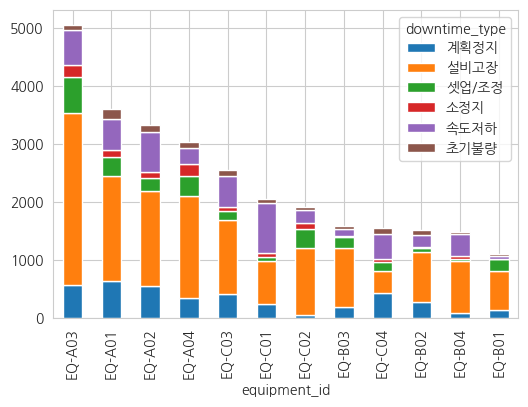

In [333]:
equip_downtime.iloc[ : , 0 : -2+1 ].plot(kind = 'bar', stacked=True, figsize=(6,4))
plt.show()

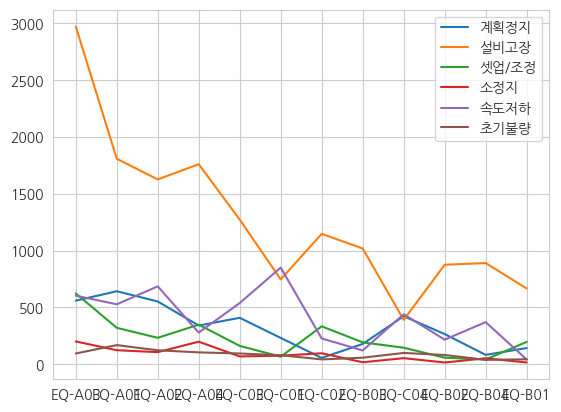

In [320]:
for c_name in equip_downtime.columns[  : -2+1 ] :
    plt.plot(equip_downtime.index, equip_downtime[c_name], label=c_name)
plt.legend()
plt.show()

### 문제 4-3: 설비고장 원인 Top 분석 (5점)

설비고장은 비가동의 가장 큰 원인입니다. 고장 원인을 세부적으로 분석합니다.

1. `downtime_type == '설비고장'`인 데이터만 필터링
2. `cause`별 건수와 총 비가동 시간을 집계
3. 라인별로 고장 원인 분포가 다른지 **그룹화 막대 차트**로 비교
4. 월별 설비고장 건수 추이를 그리세요 (개선 효과 확인)

In [337]:
# 여기에 코드 작성
failures = downtime.loc[ downtime['downtime_type'] == '설비고장', ].copy()

In [341]:
failures.columns

Index(['downtime_id', 'date', 'equipment_id', 'shift', 'downtime_type',
       'start_time', 'end_time', 'duration_min', 'cause', 'line'],
      dtype='object')

In [344]:
cause_summary = failures.groupby('cause').agg( 건수=('downtime_id','count') , 총시간=('duration_min','sum')).sort_values('총시간', ascending=False)  

In [345]:
cause_summary

,건수,총시간
cause,,
스핀들 이상,24,3132.017544
센서 오작동,19,2658.000000
모터 과열,19,2549.000000
베어링 마모,18,2440.000000
유압 누유,15,2050.000000
전기 접촉 불량,13,1597.000000
원인미상,7,756.000000


In [352]:
line_cause = failures.groupby(['line', 'cause']).size().unstack()

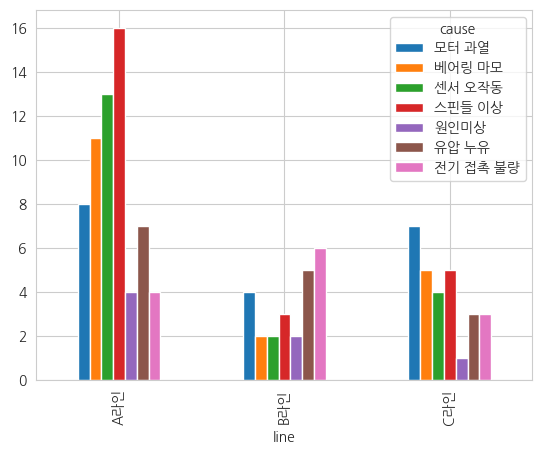

In [356]:
line_cause.plot(kind='bar')
plt.show()

In [359]:
failures['month'] = failures['date'].dt.month

In [363]:
daily_data = failures['month'].value_counts().sort_index()

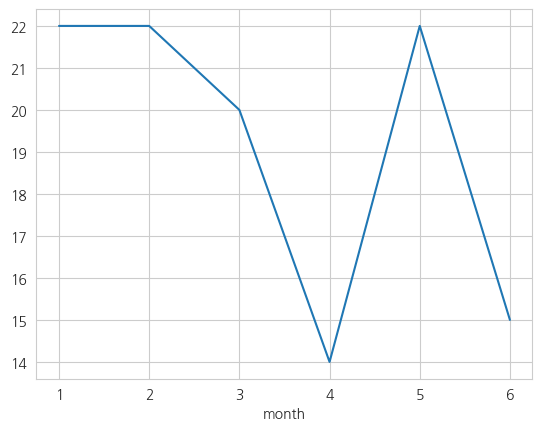

In [366]:
daily_data.plot()
plt.show()

---
## Part 5: 경영진 보고용 대시보드 (15점)

지금까지 분석한 내용을 **한 페이지 대시보드**로 정리합니다.  
경영진은 숫자보다 **시각적 요약**을 선호합니다.

> **현업 포인트**: 대시보드는 '예쁘게' 만드는 것이 아니라  
> '의사결정에 필요한 정보'를 빠르게 전달하는 것이 목표입니다.

### 문제 5-1: 종합 대시보드 (15점)

`plt.subplot()` 또는 `fig.add_subplot()`을 사용하여 **2행 3열 (6개 패널)** 대시보드를 만드세요.  
Figure 크기: (20, 12)

**패널 구성:**

| 위치 | 차트 | 내용 |
|------|------|------|
| (1,1) | 라인 차트 | 월별 OEE 추이 (라인별, 3월 개선 활동 표시) |
| (1,2) | 수평 바 차트 | 설비별 OEE 랭킹 (색상으로 등급 표시) |
| (1,3) | 히트맵 | 라인 × 월 OEE 매트릭스 |
| (2,1) | 파이 차트 | 비가동 유형별 비율 |
| (2,2) | 그룹 바 차트 | 교대조별 OEE 3요소 비교 |
| (2,3) | 박스플롯 | 라인별 불량률 분포 |

**스타일 요구사항:**
- 전체 제목: '한국정밀산업(주) 생산 효율 대시보드 (2024년 상반기)'
- 각 패널에 소제목 포함
- `plt.tight_layout()` 적용
- 필요시 OEE 등급 색상 기준: 85% 이상(녹색), 70~85%(노란색), 70% 미만(빨간색)

In [33]:
# 여기에 코드 작성


---
## 분석 결론 작성

분석 결과를 바탕으로, 아래 항목에 대해 **마크다운 셀에 직접** 작성하세요.

1. **현재 공장 OEE 수준**: World Class 기준 대비 현재 위치는?
2. **OEE를 끌어내리는 주요 요인**: 가동률/성능률/양품률 중 어느 것이 가장 문제인가?
3. **개선 활동 효과**: 3월 이후 실제로 OEE가 개선되었는가? 얼마나?
4. **라인별 차이**: A/B/C 라인 간 차이의 원인은?
5. **우선 개선 대상**: 가장 먼저 개선해야 할 설비 또는 로스 유형은?
6. **구체적 개선 제안**: 데이터에 근거한 3가지 이상의 개선 방안

### 분석 결론 (여기에 작성)

1. **현재 공장 OEE 수준**: 

2. **OEE를 끌어내리는 주요 요인**: 

3. **개선 활동 효과**: 

4. **라인별 차이**: 

5. **우선 개선 대상**: 

6. **구체적 개선 제안**: 


---
## 수고하셨습니다!

### 학습 체크리스트
- [ ] 현장 데이터 결측치 확인 및 전처리
- [ ] IQR 기반 이상치 탐지
- [ ] 여러 테이블 Left Join 결합
- [ ] OEE 3요소(가동률·성능률·양품률) 직접 계산
- [ ] 설비별·라인별·월별 OEE 집계 및 비교
- [ ] 개선 전/후 효과 검증 (t-test)
- [ ] Six Big Losses 파레토 분석
- [ ] 이중 y축 차트, 히트맵, 파이 차트 등 다양한 시각화
- [ ] 6패널 종합 대시보드 구성
- [ ] 데이터 기반 개선 제안 도출